In [117]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import RFE
from sklearn.pipeline import Pipeline
from sklearn.decomposition import KernelPCA

%matplotlib inline

In [118]:
import mnists
mnist = mnists.MNIST()

NUM_OF_SAMPLES=12*24*3

# digits = np.reshape(mnist.train_images()[:12*24], newshape=(12, 24, 28, 28))
digits = mnist.train_images()[:NUM_OF_SAMPLES]
digits.shape

(864, 28, 28)

In [119]:
digits = digits.reshape(digits.shape[0], -1)
digits.shape

(864, 784)

In [120]:
X = digits / 255
y = mnist.train_labels()[:NUM_OF_SAMPLES]

In [121]:
def plot_2d(X, y):
    X = np.asarray(X)
    y = np.asarray(y)

    plt.figure(figsize=(8, 6))

    scatter = plt.scatter(
        X[:, 0],
        X[:, 1],
        c=y,
        cmap='tab10',
        s=10,
        alpha=0.7
    )

    plt.colorbar(scatter)
    plt.show()
#

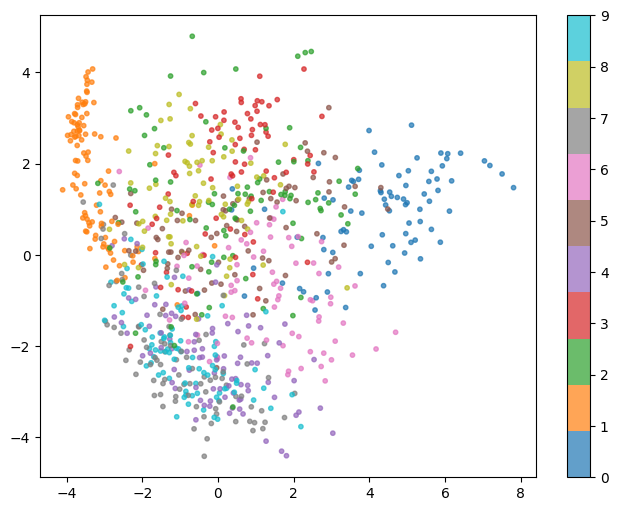

array([0.1016133 , 0.07704084, 0.06612279, 0.0548617 , 0.04978772,
       0.04614309, 0.0343924 , 0.03194815, 0.02817476, 0.02193227,
       0.02043022, 0.01864256, 0.01776033, 0.01729379, 0.01597416])

In [122]:
pca = PCA(n_components=15)

plot_2d(
    pca.fit_transform(X),
    y
)

explained_variance = pca.explained_variance_ratio_
explained_variance

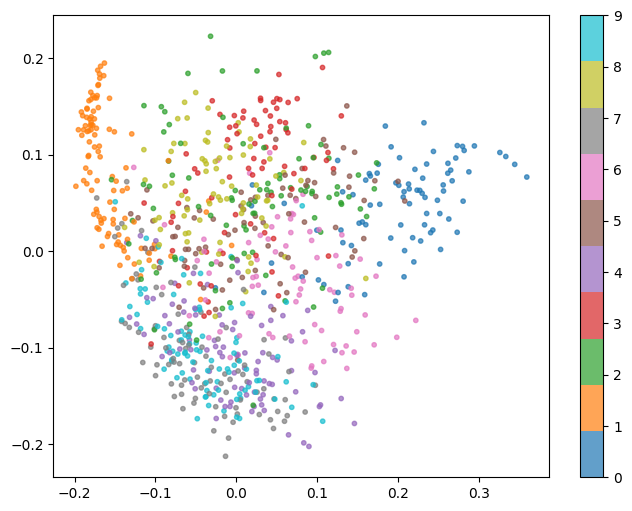

In [123]:
kernel_pca = KernelPCA(
    kernel='rbf',
    n_components=15
)

plot_2d(
    kernel_pca.fit_transform(X),
    y
)

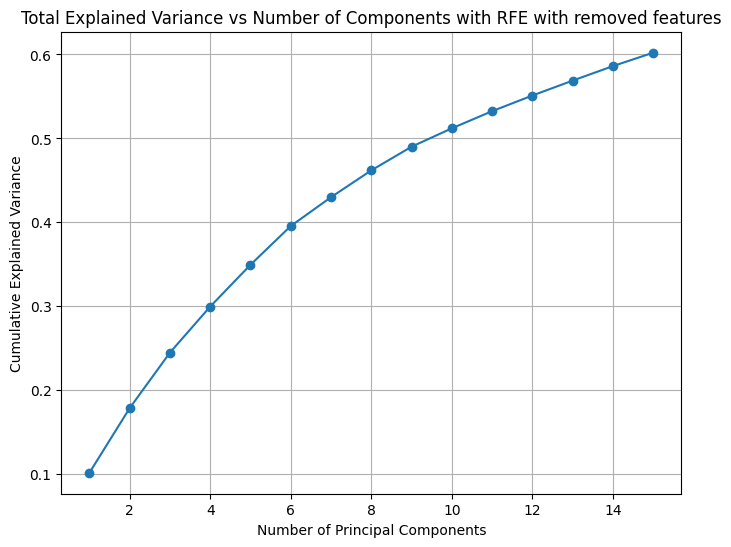

In [124]:
explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

plt.figure(figsize=(8,6))

plt.plot(
    range(1, len(cumulative_variance) + 1),
    cumulative_variance,
    marker="o"
)

plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Total Explained Variance vs Number of Components with RFE with removed features")
plt.grid(True)
plt.show()

In [125]:
#  Jak widać, skumulowana wyjaśnialna wariancja dość wolno zbiega do 1. Sugeruje to, że dane są dosć złożone i liniowa transformacja nie radzi sobie dobrze.

In [126]:
pca = PCA()
pca.fit(X)
cumulative_variance = np.cumsum(pca.explained_variance_ratio_)

thresholds = [0.99, 0.95, 0.90, 0.85, 0.6, 0.3, 0.2]
n_components = {}

for t in thresholds:
    n = np.searchsorted(cumulative_variance, t) + 1
    n_components[t] = n

print(n_components)

{0.99: 267, 0.95: 126, 0.9: 75, 0.85: 52, 0.6: 15, 0.3: 5, 0.2: 3}


In [127]:
# arrange 2D matrices as tiles (takes 4D `examples` tensor with dims: rows x cols x tile_height x tile_width)
def tiles(examples: np.ndarray):
    rows_count, cols_count, tile_height, tile_width = examples.shape

    space_between_tiles = 2
    img_matrix = np.empty(shape=(
        rows_count * (tile_height + space_between_tiles) - space_between_tiles,
        cols_count * (tile_width + space_between_tiles) - space_between_tiles
    ))
    img_matrix.fill(np.nan)

    for y in range(rows_count):
        for x in range(cols_count):
            start_y = y * (tile_height + space_between_tiles)
            start_x = x * (tile_width + space_between_tiles)
            img_matrix[start_y : start_y + tile_height, start_x : start_x + tile_width] = examples[y, x]

    return img_matrix

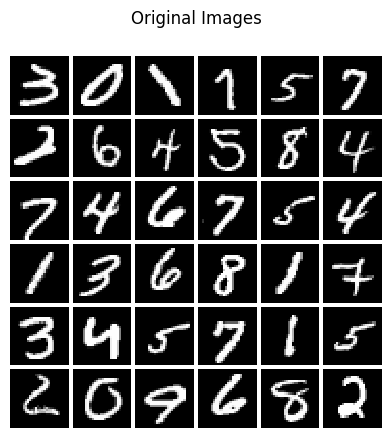

In [130]:
rows = 6
cols = 6
num_samples = rows * cols

indices = np.random.choice(len(X), num_samples, replace=False)
X_samples = X[indices]

digits_original = X_samples.reshape(rows, cols, 28, 28)
img_original = tiles(digits_original)

plt.matshow(img_original, cmap='gray', interpolation='none')
plt.axis('off')
plt.title("Original Images")
plt.show()


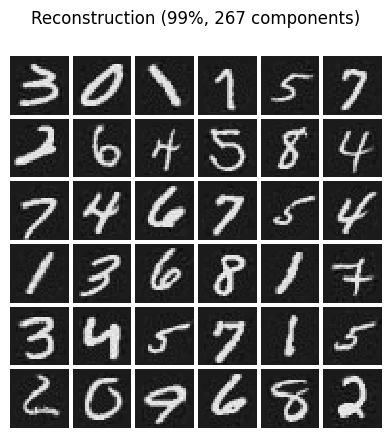

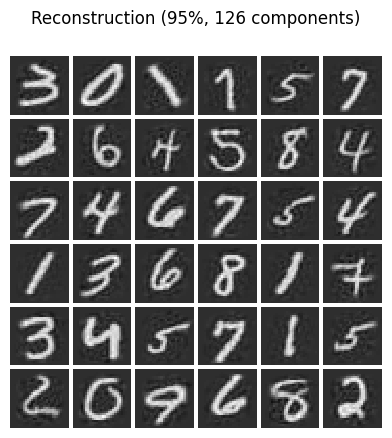

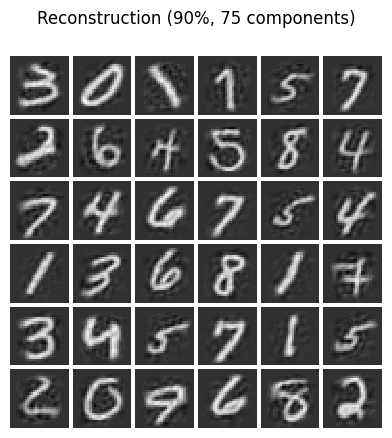

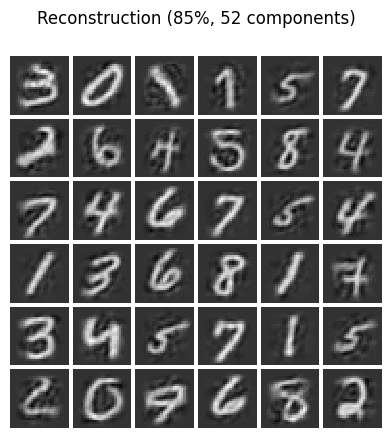

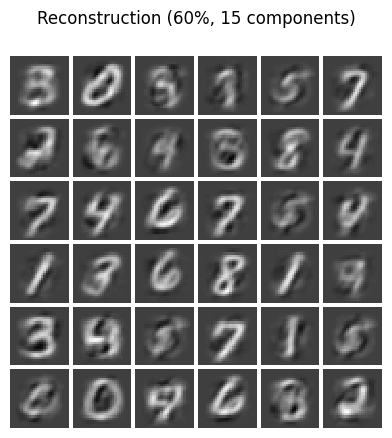

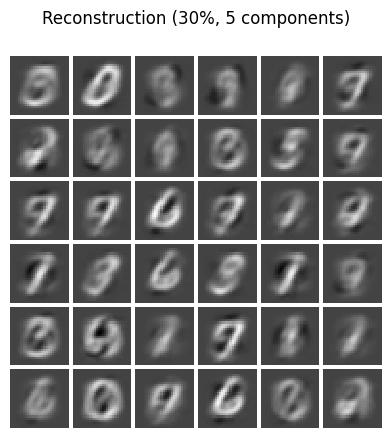

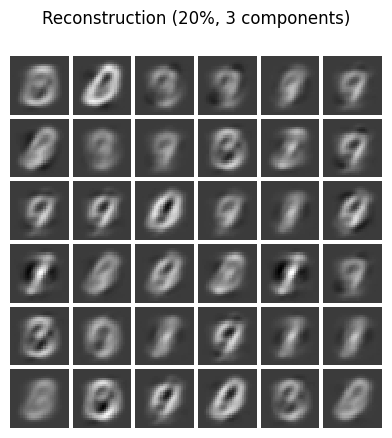

In [131]:
for t in thresholds:
    n = n_components[t]

    pca = PCA(n_components=n)
    X_reduced = pca.fit_transform(X)
    X_reconstructed = pca.inverse_transform(X_reduced)

    X_rec_samples = X_reconstructed[indices]
    digits_rec = X_rec_samples.reshape(rows, cols, 28, 28)
    img_rec = tiles(digits_rec)

    plt.matshow(img_rec, cmap='gray', interpolation='none')
    plt.axis('off')
    plt.title(f"Reconstruction ({int(t*100)}%, {n} components)")
    plt.show()

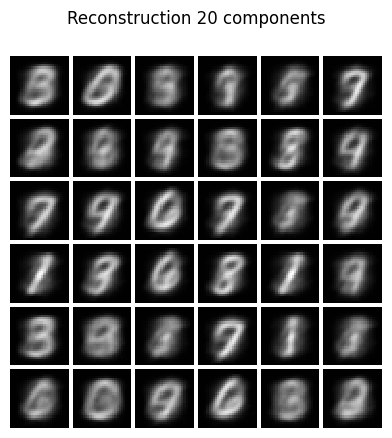

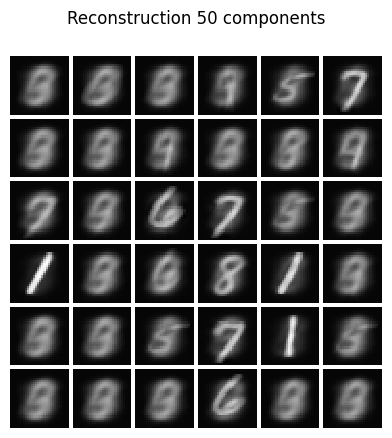

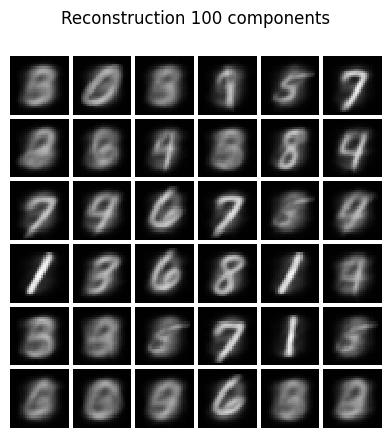

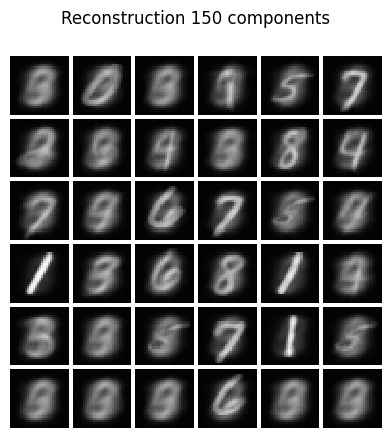

In [146]:
gamma_lists = [0.01, 0.1, 0.05, 0.1]
n_components = [20, 50, 100, 150]

for i in range(len(n_components)):

    kernel_pca = KernelPCA(
        kernel='rbf',
        gamma=gamma_lists[i],
        n_components=n_components[i],
        fit_inverse_transform=True
    )

    X_reduced = kernel_pca.fit_transform(X)
    X_reconstructed = kernel_pca.inverse_transform(X_reduced)

    X_rec_samples = X_reconstructed[indices]
    digits_rec = X_rec_samples.reshape(rows, cols, 28, 28)
    img_rec = tiles(digits_rec)

    plt.matshow(img_rec, cmap='gray', interpolation='none')
    plt.axis('off')
    plt.title(f"Reconstruction {n_components[i]} components")
    plt.show()

1. Rzeczywiście, PCA jest bardzo ciekawą metodą redukcji wymiarowości i wizualizacji danych, zwłaszcza w przestrzeni 2D i 3D. Klasyczne PCA może służyć do wykrywania liniowych zależności między danymi oraz oceny złożoności problemu na podstawie skumulowanej wariancji. Kernel PCA jest nieco bardziej złożone, ale pozwala rozdzielać klasy, które nie są liniowo separowalne. Jego główną trudnością jest dobór hiperparametrów - często trzeba testować wiele kombinacji, na przykład z użyciem GridSearch.

2. Tak, te narzędzia są przydatne w rzeczywistych scenariuszach. Wiele modeli ma określone założenia, na przykład dane nie powinny być silnie skorelowane. Zastosowanie PCA może usunąć zduplikowane atrybuty. Ponadto część modeli ma problem tzw. przekleństwa wymiarowości, czyli trudności z dużą liczbą cech, na przykład KNN. Przed użyciem takich modeli często konieczna jest redukcja wymiarowości, którą można wykonać za pomocą PCA.

3. Złożoność obliczeniowa:
Klasyczne PCA jest stosunkowo szybkie dla średnich zbiorów danych, jednak przy bardzo dużej liczbie cech lub próbek może być kosztowne. Kernel PCA jest bardziej wymagające obliczeniowo, ponieważ musi obliczyć macierz podobieństwa między wszystkimi próbkami, przez co jego koszt szybko rośnie wraz ze wzrostem liczby danych.

4. Możliwe ulepszenia:
Można stosować wersje przybliżone lub przyrostowe PCA dla dużych zbiorów danych. W przypadku Kernel PCA warto dobierać hiperparametry z użyciem walidacji krzyżowej oraz ograniczać liczbę próbek, jeśli to możliwe.